In [10]:
import pandas as pd
df = pd.read_csv("stops.csv")
df.head()

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon
0,1,NaN,Dilshad Garden,NaN,28.675991,77.321495
1,2,NaN,Jhilmil,NaN,28.675648,77.312393
2,3,NaN,Mansrover park,NaN,28.675352,77.301178
3,4,NaN,Shahdara,NaN,28.673531,77.287270
4,5,NaN,Welcome,NaN,28.671986,77.277931


In [11]:
# This counts exactly how many NaN (blank) values are hiding in every single column
df.isnull().sum()

stop_id        0
stop_code    262
stop_name      0
stop_desc    262
stop_lat       0
stop_lon       0
dtype: int64

In [12]:
# Drop the empty columns and save the result as a new variable
df_cleaned = df.drop(columns=['stop_code', 'stop_desc'])

df_cleaned.head()

,stop_id,stop_name,stop_lat,stop_lon
0,1,Dilshad Garden,28.675991,77.321495
1,2,Jhilmil,28.675648,77.312393
2,3,Mansrover park,28.675352,77.301178
3,4,Shahdara,28.673531,77.287270
4,5,Welcome,28.671986,77.277931


In [13]:
df.isnull().sum()


stop_id        0
stop_code    262
stop_name      0
stop_desc    262
stop_lat       0
stop_lon       0
dtype: int64

In [14]:
# Now checking the new and cleaned dataset instead of the old one
df_cleaned.isnull().sum()

stop_id      0
stop_name    0
stop_lat     0
stop_lon     0
dtype: int64

In [ ]:
# Save the cleaned data
df_cleaned.to_csv("cleaned_stops.csv", index=False)

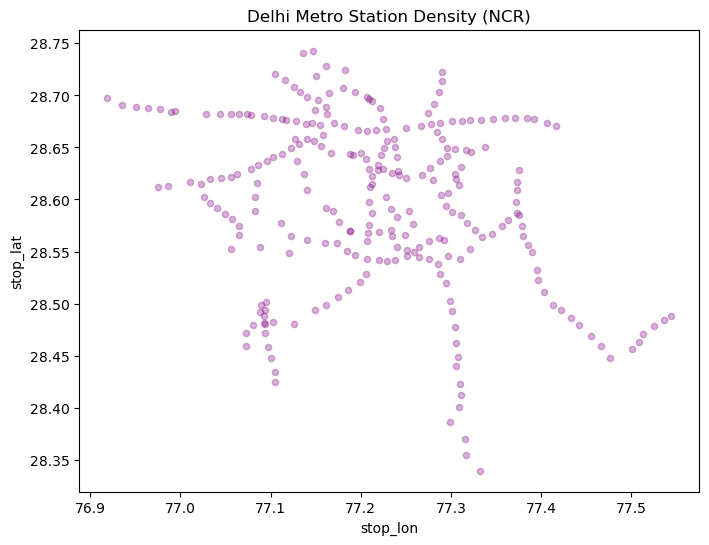

In [ ]:
# Import the plotting tool
import matplotlib.pyplot as plt

# Now telling Pandas to create a scatter plot using our coordinates
df_cleaned.plot(
    kind='scatter', 
    x='stop_lon',     # Longitude is the X-axis East/West 
    y='stop_lat',     # Latitude is the Y-axis North/South
    alpha=0.3,        # making the dots a little transparent so we can see density
    color='purple',   # just a personal preference for purple, you can change it to any color you like!
    figsize=(8, 6)    # Makes the graph large enough to read easily
)

# Add a title to the map
plt.title("Delhi Metro Station Density (NCR)")

# Display the map
plt.show()

Geographic Insight: This visualization maps 262 active transit stations. We observe a high-density transit hub in Central Delhi, with linear corridors extending outward to service the broader NCR, highlighting critical urban mobility arteries.

In [ ]:
# Load the routes dataset
df_routes = pd.read_csv("routes.csv")

# Display the first 5 rows to see what information the government provided
df_routes.head()

,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type,route_url,route_color,route_text_color,route_sort_order,continuous_pickup,continuous_drop_off
0,33,NaN,R_SP_R,RAPID_Phase 3 (Rapid Metro) to Sector 55-56 (R...,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
1,31,NaN,G_DD_R,GRAY_Dhansa Bus Stand to Dwarka,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
2,29,NaN,P_MS_R,PINK_Shiv Vihar to Majlis Park,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
3,12,NaN,M_JB,MAGENTA_Janak Puri West to Botanical Garden,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
4,11,NaN,P_MS,PINK_Majlis Park to Shiv Vihar,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# 1. We tell Pandas to look at the route_long_name column as a string (.str)
# 2. We split it into pieces at every underscore (.split('_'))
# 3. We grab the very first piece, which in Python is index 0 (.str[0])
# 4. We save that piece into a brand new column called 'color_name'

df_routes['color_name'] = df_routes['route_long_name'].str.split('_').str[0]

# Let's look at just our old column and our new column side-by-side to verify
df_routes[['route_long_name', 'color_name']].head()

,route_long_name,color_name
0,RAPID_Phase 3 (Rapid Metro) to Sector 55-56 (R...,RAPID
1,GRAY_Dhansa Bus Stand to Dwarka,GRAY
2,PINK_Shiv Vihar to Majlis Park,PINK
3,MAGENTA_Janak Puri West to Botanical Garden,MAGENTA
4,PINK_Majlis Park to Shiv Vihar,PINK


In [19]:
# 1. Load the missing bridge datasets
df_trips = pd.read_csv("trips.csv")
df_stop_times = pd.read_csv("stop_times.csv")

# 2. Merge 1: Connect routes to trips (using the shared 'route_id' column)
step_1 = pd.merge(df_routes, df_trips, on='route_id')

# 3. Merge 2: Connect the result to stop_times (using the shared 'trip_id' column)
step_2 = pd.merge(step_1, df_stop_times, on='trip_id')

# 4. Merge 3: Connect the final result to our cleaned stops (using the shared 'stop_id')
final_df = pd.merge(step_2, df_cleaned, on='stop_id')

# 5. Clean up: Since multiple trains visit the same station every day, 
# we want to drop duplicates so we only have ONE dot per station on our map.
final_mapped_df = final_df.drop_duplicates(subset=['stop_id'])

# Show the final result: Station Name, Color, and GPS Coordinates!
final_mapped_df[['stop_name', 'color_name', 'stop_lat', 'stop_lon']].head()

,stop_name,color_name,stop_lat,stop_lon
0,Phase 3 (Rapid Metro),RAPID,28.494329,77.093552
1,Moulsari Avenue (Rapid Metro),RAPID,28.501572,77.094536
2,Cyber City (Rapid Metro),RAPID,28.498478,77.089088
3,Belvedere Towers (Rapid Metro),RAPID,28.492065,77.088142
4,Phase 2 (Rapid Metro),RAPID,28.488371,77.092865


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. We create a custom "palette" (a dictionary) linking the text to actual colors
metro_palette = {
    'RED': 'red',
    'BLUE': 'blue',
    'YELLOW': '#FFD700',   # A nice gold/yellow
    'GREEN': 'green',
    'VIOLET': 'purple',
    'PINK': 'pink',
    'MAGENTA': 'magenta',
    'ORANGE': 'orange',
    'GRAY': 'gray',
    'RAPID': 'cyan',       # Rapid Metro is usually cyan/light blue
    'AQUA': 'teal'         # Aqua Line
}

# 2. Set up the "canvas" size
plt.figure(figsize=(12, 10))

# 3. Draw the scatter plot using Seaborn!
# We tell it to use 'color_name' for the 'hue' (the color of the dots)
sns.scatterplot(
    data=final_mapped_df, 
    x='stop_lon', 
    y='stop_lat', 
    hue='color_name',      # This separates the dots by line!
    palette=metro_palette, # This applies our custom colors
    s=60,                  # Size of the dots
    alpha=0.8,             # Slight transparency
    edgecolor='black'      # A tiny border around each dot for a clean look
)

# 4. Add a professional title and clean up the visual layout
plt.title("Delhi Metro Network (Color-Coded by Line)", fontsize=16)
plt.legend(title="Metro Lines", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 5. Display the masterpiece
plt.show()

ValueError: The palette dictionary is missing keys: {'ORANGE/AIRPORT'}

<Figure size 1200x1000 with 0 Axes>

Okay so ran in some problem figured it out the government data has not assigned the ORANGE/AIRPORT lets try to tweak our metro_pallete a bit and then see if it gets corrected!

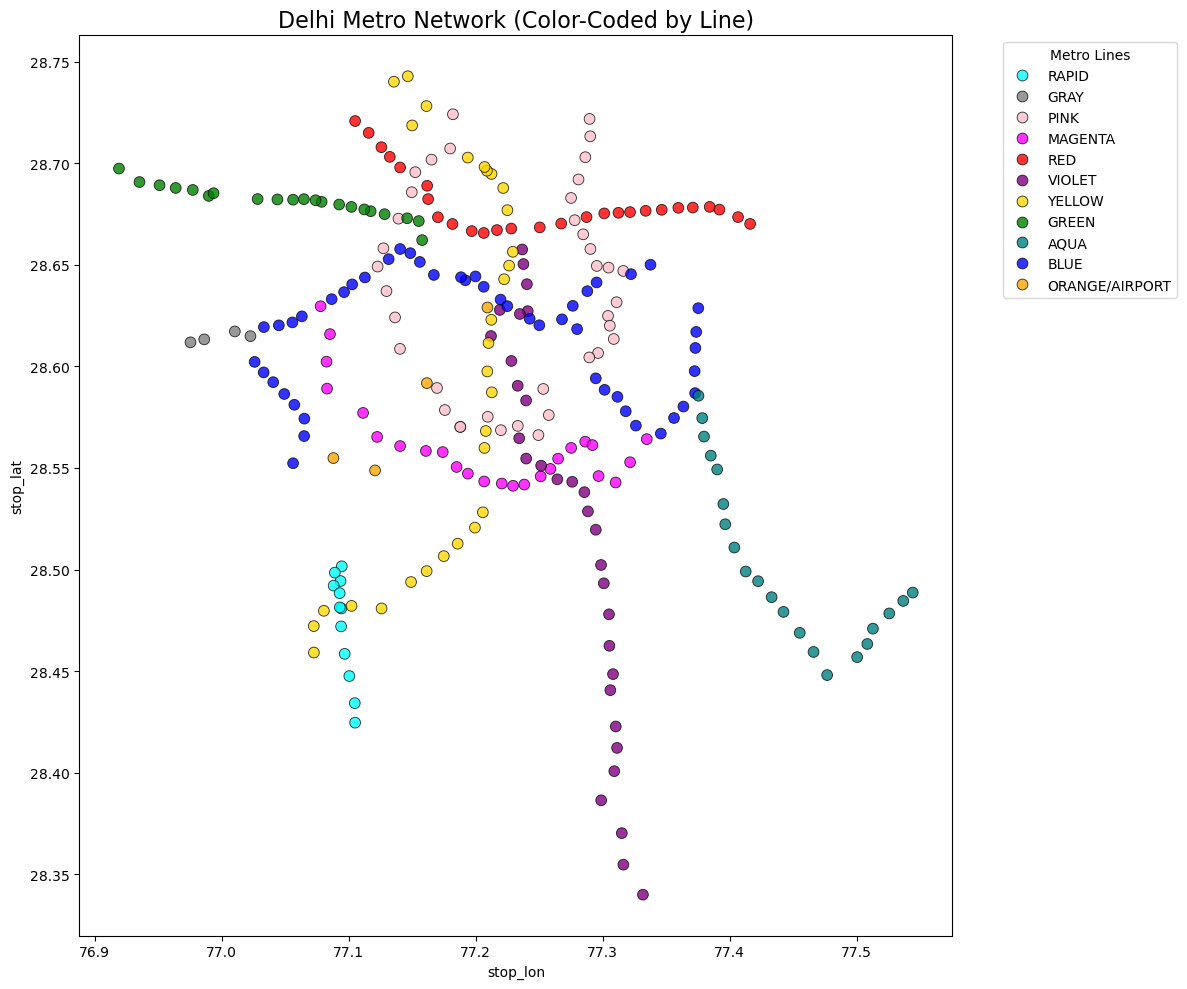

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. We update our palette to include the exact edge case the error caught
metro_palette = {
    'RED': 'red',
    'BLUE': 'blue',
    'YELLOW': '#FFD700',   
    'GREEN': 'green',
    'VIOLET': 'purple',
    'PINK': 'pink',
    'MAGENTA': 'magenta',
    'ORANGE': 'orange',
    'ORANGE/AIRPORT': 'orange',  # <-- Here is the fix!
    'GRAY': 'gray',
    'RAPID': 'cyan',       
    'AQUA': 'teal'         
}

# 2. Set up the "canvas" size
plt.figure(figsize=(12, 10))

# 3. Draw the scatter plot using Seaborn
sns.scatterplot(
    data=final_mapped_df, 
    x='stop_lon', 
    y='stop_lat', 
    hue='color_name',      
    palette=metro_palette, 
    s=60,                  
    alpha=0.8,             
    edgecolor='black'      
)

# 4. Add a professional title and clean up the visual layout
plt.title("Delhi Metro Network (Color-Coded by Line)", fontsize=16)
plt.legend(title="Metro Lines", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 5. Display the masterpiece
plt.show()